In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering import AgglomerativeClustering
from sklearn.metrics import silhouette_score


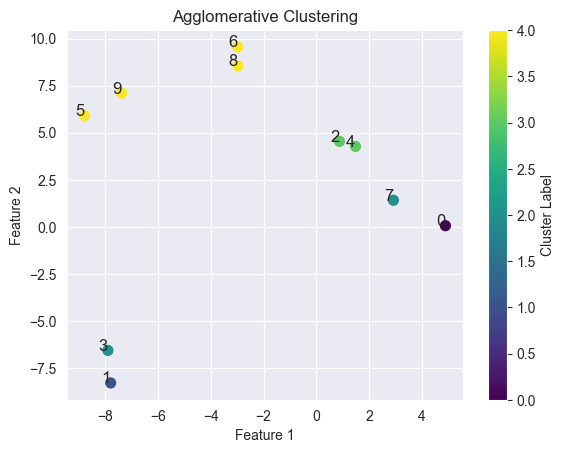

In [22]:
X, y = make_blobs(n_samples=10, centers=5, cluster_std=1,random_state=42)

# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=3, n_clusters=5,linkage="complete")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.K_clusters):
    for point_index in node.points:
        cluster_labels[point_index] = idx
    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [20]:
model.linkage_matrix

[[2, 4, np.float64(0.6618782021352919), 2],
 [6, 8, np.float64(1.0083079879584977), 2],
 [0, 7, np.float64(2.3861681962785877), 2],
 [1, 3, np.float64(1.7297291664908654), 2],
 [5, 9, np.float64(1.841812882704573), 2],
 [11, 14, np.float64(6.85056407548658), 4],
 [10, 12, np.float64(6.0108439418916975), 4],
 [15, 16, np.float64(14.848810673378926), 8],
 [13, 17, np.float64(18.485733553190492), 10]]

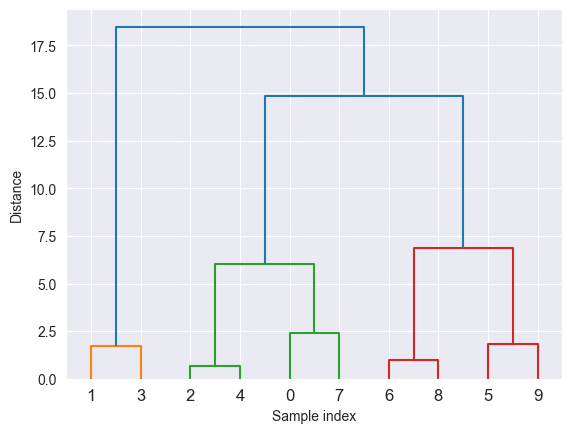

In [18]:
model.plot_dendrogram()

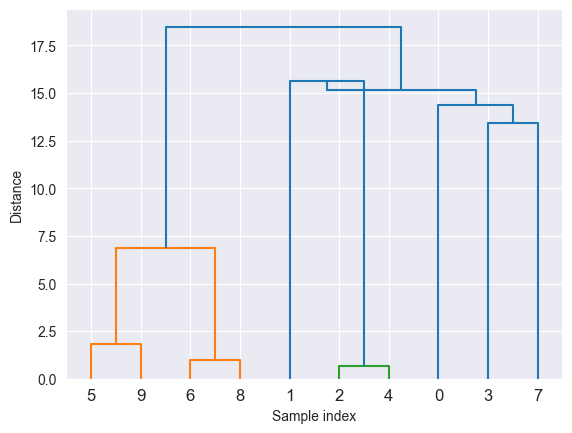

In [23]:
model.plot_dendrogram()

## Plots for Silhouette Scores for different values of  $\tau$
an average silhouette width of over 0.7 is considered to be "strong", a value over 0.5 "reasonable" and over 0.25 "weak"

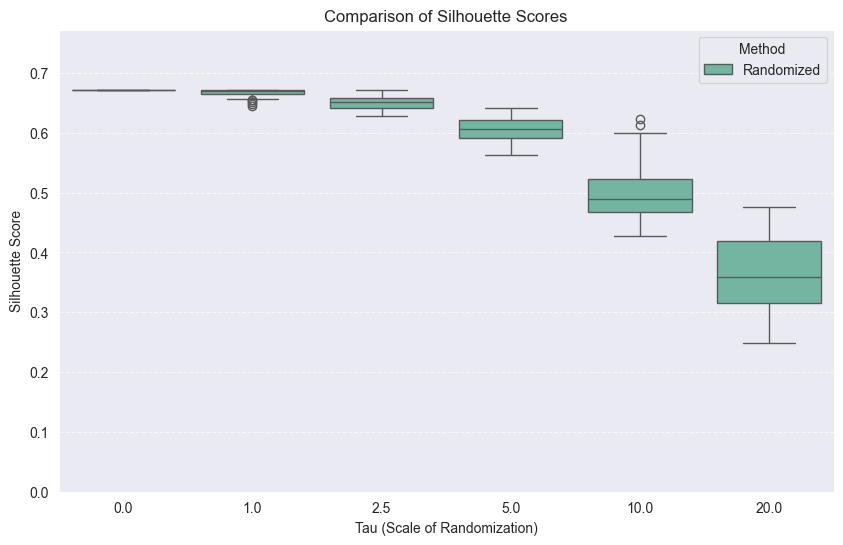

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define a range of tau values
n = 200
tau_values = [0,1,2.5,5,10,20]
n_runs = 50
n_clusters = 5  
# Data collection
results = []

for tau in tau_values:
    for _ in range(n_runs):
        X, y = make_blobs(n_samples=n, centers=5, cluster_std=1,random_state=42)
        # Randomized hierarchical clustering
        randomized_clustering = AgglomerativeClustering(X, n_clusters=n_clusters, tau=tau)
        randomized_clustering.fit()
        randomized_score = randomized_clustering.compute_silhouette_score()
        results.append({'Tau': tau, 'Method': 'Randomized', 'Silhouette Score': randomized_score})

# Convert results to a DataFrame
df = pd.DataFrame(results)

# Create side-by-side boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Tau', y='Silhouette Score', hue='Method', palette='Set2')
plt.title('Comparison of Silhouette Scores')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('Silhouette Score')
plt.legend(title='Method')
y_max = df['Silhouette Score'].max() 
plt.ylim(0, y_max + 0.1) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Plot of within-cluster sum of square
$$
WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2
$$

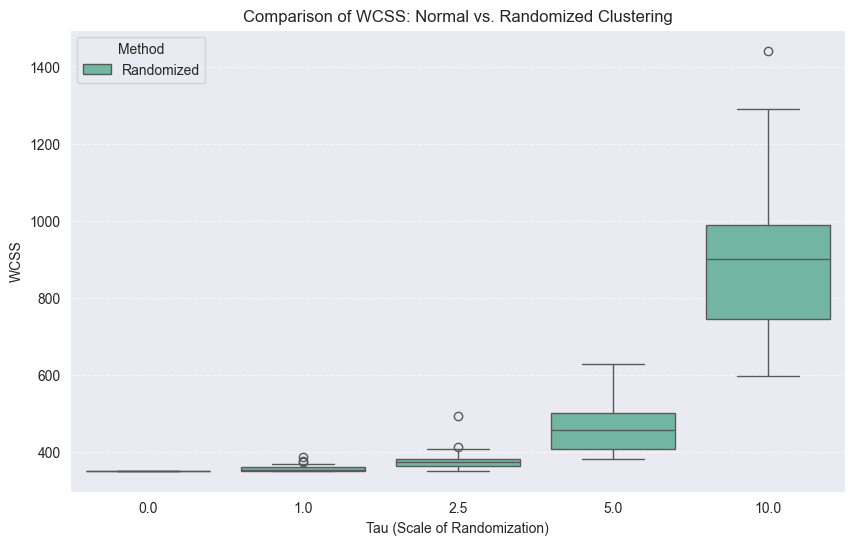

In [18]:
n = 200
tau_values = [0,1,2.5,5,10]
n_runs = 50
n_clusters = 5  
# Data collection
results = []

for tau in tau_values:
    for _ in range(n_runs):
        X, y = make_blobs(n_samples=n, centers=5, cluster_std=1,random_state=42)
        # Randomized hierarchical clustering
        randomized_clustering = AgglomerativeClustering(X, n_clusters=n_clusters, tau=tau)
        randomized_clustering.fit()
        randomized_score = randomized_clustering.compute_wcss()
        results.append({'Tau': tau, 'Method': 'Randomized', 'WCSS': randomized_score})

# Convert results to a DataFrame
df = pd.DataFrame(results)

# Create side-by-side boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Tau', y='WCSS', hue='Method', palette='Set2')
plt.title('Comparison of WCSS: Normal vs. Randomized Clustering')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('WCSS')
plt.legend(title='Method')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

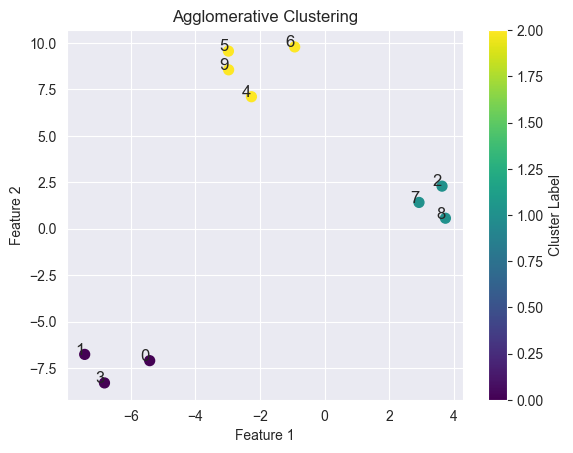

In [2]:
X, y = make_blobs(n_samples=10, centers=3, cluster_std=1,random_state=42)

# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=3,linkage="ward")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [3]:
print("Distance Log:")
for key, value in model.distance_log.items():
    print(f"{key}: {value}")

Distance Log:
(ClusterNode(points=[0]), ClusterNode(points=[1])): 2.0380364931244994
(ClusterNode(points=[0]), ClusterNode(points=[2])): 13.037418962158593
(ClusterNode(points=[0]), ClusterNode(points=[3])): 1.8418128827045737
(ClusterNode(points=[0]), ClusterNode(points=[4])): 14.551211837000686
(ClusterNode(points=[0]), ClusterNode(points=[5])): 16.83975525993707
(ClusterNode(points=[0]), ClusterNode(points=[6])): 17.472763390969146
(ClusterNode(points=[0]), ClusterNode(points=[7])): 11.912454405048726
(ClusterNode(points=[0]), ClusterNode(points=[8])): 11.934209188039876
(ClusterNode(points=[0]), ClusterNode(points=[9])): 15.843668027053912
(ClusterNode(points=[1]), ClusterNode(points=[2])): 14.288035244679854
(ClusterNode(points=[1]), ClusterNode(points=[3])): 1.653093983207061
(ClusterNode(points=[1]), ClusterNode(points=[4])): 14.797789518418515
(ClusterNode(points=[1]), ClusterNode(points=[5])): 16.920413362187247
(ClusterNode(points=[1]), ClusterNode(points=[6])): 17.7793395019

In [4]:
print("\nExisting Clusters Log:")
for key, value in model.existing_clusters_log.items():
    print(f"Merge: {key} -> Clusters: {value}")


Existing Clusters Log:
Merge: (ClusterNode(points=[0]), ClusterNode(points=[3])) -> Clusters: [ClusterNode(points=[0]), ClusterNode(points=[1]), ClusterNode(points=[2]), ClusterNode(points=[3]), ClusterNode(points=[4]), ClusterNode(points=[5]), ClusterNode(points=[6]), ClusterNode(points=[7]), ClusterNode(points=[8]), ClusterNode(points=[9])]
Merge: (ClusterNode(points=[1]), ClusterNode(points=[0, 3])) -> Clusters: [ClusterNode(points=[1]), ClusterNode(points=[2]), ClusterNode(points=[4]), ClusterNode(points=[5]), ClusterNode(points=[6]), ClusterNode(points=[7]), ClusterNode(points=[8]), ClusterNode(points=[9]), ClusterNode(points=[0, 3])]
Merge: (ClusterNode(points=[5]), ClusterNode(points=[9])) -> Clusters: [ClusterNode(points=[2]), ClusterNode(points=[4]), ClusterNode(points=[5]), ClusterNode(points=[6]), ClusterNode(points=[7]), ClusterNode(points=[8]), ClusterNode(points=[9]), ClusterNode(points=[1, 0, 3])]
Merge: (ClusterNode(points=[7]), ClusterNode(points=[8])) -> Clusters: [C

In [5]:
print("Randomization Log:")
for key, value in model.randomization_log.items():
    print(f"{key}: {value}")


Randomization Log:
1: {(ClusterNode(points=[0]), ClusterNode(points=[1])): -0.4192074051290811, (ClusterNode(points=[0]), ClusterNode(points=[2])): -0.7935946561435466, (ClusterNode(points=[0]), ClusterNode(points=[3])): -1.2263485822149047, (ClusterNode(points=[0]), ClusterNode(points=[4])): 0.39471829023268545, (ClusterNode(points=[0]), ClusterNode(points=[5])): 1.4496246917224627, (ClusterNode(points=[0]), ClusterNode(points=[6])): 0.3795445036203365, (ClusterNode(points=[0]), ClusterNode(points=[7])): 0.7066616343500404, (ClusterNode(points=[0]), ClusterNode(points=[8])): -1.2548559767210463, (ClusterNode(points=[0]), ClusterNode(points=[9])): 1.00288313673437, (ClusterNode(points=[1]), ClusterNode(points=[2])): -0.8198140245176877, (ClusterNode(points=[1]), ClusterNode(points=[3])): 1.754963101178705, (ClusterNode(points=[1]), ClusterNode(points=[4])): 0.478063237311549, (ClusterNode(points=[1]), ClusterNode(points=[5])): -0.10320642933805017, (ClusterNode(points=[1]), ClusterNode

In [6]:
print(model.final_step)

7


In [7]:
node = model.cluster_nodes[1]
p1 = node.left
p2 = node.right

In [8]:
model.existing_clusters_log.keys()

dict_keys([(ClusterNode(points=[0]), ClusterNode(points=[3])), (ClusterNode(points=[1]), ClusterNode(points=[0, 3])), (ClusterNode(points=[5]), ClusterNode(points=[9])), (ClusterNode(points=[7]), ClusterNode(points=[8])), (ClusterNode(points=[2]), ClusterNode(points=[7, 8])), (ClusterNode(points=[4]), ClusterNode(points=[5, 9])), (ClusterNode(points=[6]), ClusterNode(points=[4, 5, 9]))])

In [9]:
def find_key_index(target_key, dictionary):
    for idx, key in enumerate(dictionary.keys()):
        if key == target_key:
            return idx
    return -1 

find_key_index((p1,p2),model.existing_clusters_log)

4

In [11]:
node

ClusterNode(points=[2, 7, 8])